# Cluster HFpEF

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_100, get_hfpef_100_nomiss_selected_feats, convert2np

In [2]:
no_clusters = 8
lbl_colname= ['Death', 'CV death', 'HF hospitalization']

## Get Data

In [3]:
data_df = get_hfpef_100()

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98 entries, 0 to 99
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 98 non-null     int64  
 1   Sex                 98 non-null     int64  
 2   Cr                  98 non-null     float64
 3   GFR                 98 non-null     float64
 4   CKD stage           98 non-null     int64  
 5   smoke               98 non-null     float64
 6   BMI                 98 non-null     float64
 7   DM                  98 non-null     int64  
 8   Insulin             98 non-null     int64  
 9   AF                  98 non-null     int64  
 10  SBP                 98 non-null     float64
 11  DBP                 98 non-null     float64
 12  MAP                 98 non-null     float64
 13  PP                  98 non-null     int64  
 14  HR                  98 non-null     float64
 15  ACE-i               98 non-null     int64  
 16  ARB       

In [6]:
data_df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,DM,Insulin,AF,...,e/E',lateral e/E',E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LAVI,LA diameter,LVEF
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,71.959184,1.663265,1.785408,50.869592,2.846939,0.132653,21.114286,0.581633,0.316327,0.367347,...,14.155561,12.738469,0.782552,16.743163,2.015612,0.698551,115.998878,27.176531,2.545612,62.105102
std,11.604228,0.475023,1.570997,26.728925,1.096875,0.340943,11.354485,0.495827,0.467433,0.484561,...,7.488935,6.640708,0.691967,8.067268,1.439859,0.422547,53.494470,26.203525,2.147586,7.225176
min,34.000000,1.000000,0.550000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000
25%,65.000000,1.000000,0.892500,27.250000,2.000000,0.000000,18.700000,0.000000,0.000000,0.000000,...,9.812500,8.625000,0.500000,11.800000,0.000000,0.432500,85.075000,0.000000,0.000000,56.000000
50%,74.000000,2.000000,1.170000,52.000000,3.000000,0.000000,23.300000,1.000000,0.000000,0.000000,...,13.615000,12.150000,0.700000,16.300000,2.575000,0.580000,113.850000,28.050000,3.600000,61.250000
75%,79.000000,2.000000,1.982500,68.750000,4.000000,0.000000,28.475000,1.000000,1.000000,1.000000,...,18.825000,16.575000,1.000000,20.850000,3.040000,0.900000,138.905000,44.725000,4.400000,67.300000
max,97.000000,2.000000,10.000000,105.000000,5.000000,1.000000,45.000000,1.000000,1.000000,1.000000,...,33.750000,30.700000,4.100000,42.200000,4.550000,2.300000,356.600000,107.700000,6.000000,80.000000


## 1. All Features

In [7]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from utils import get_score, score_columns, plot_clustering_score, plot_contingency_matrix, plot_bic_aic

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [8]:
X, y, feature_list = convert2np(data_df, lbl_colname)

In [9]:
def get_km_pred(k, X):
    km = KMeans(n_clusters=k, random_state=0)
    return km.fit_predict(X)

def get_sc_pred(k, X):
    sc = SpectralClustering(n_clusters=k, eigen_solver='arpack', affinity="nearest_neighbors", random_state=0)
    return sc.fit_predict(X)

def get_gm_pred(k, X):
    gm = GaussianMixture(n_components=k, random_state=0, init_params='kmeans').fit(X)
    return gm.predict(X)

In [10]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

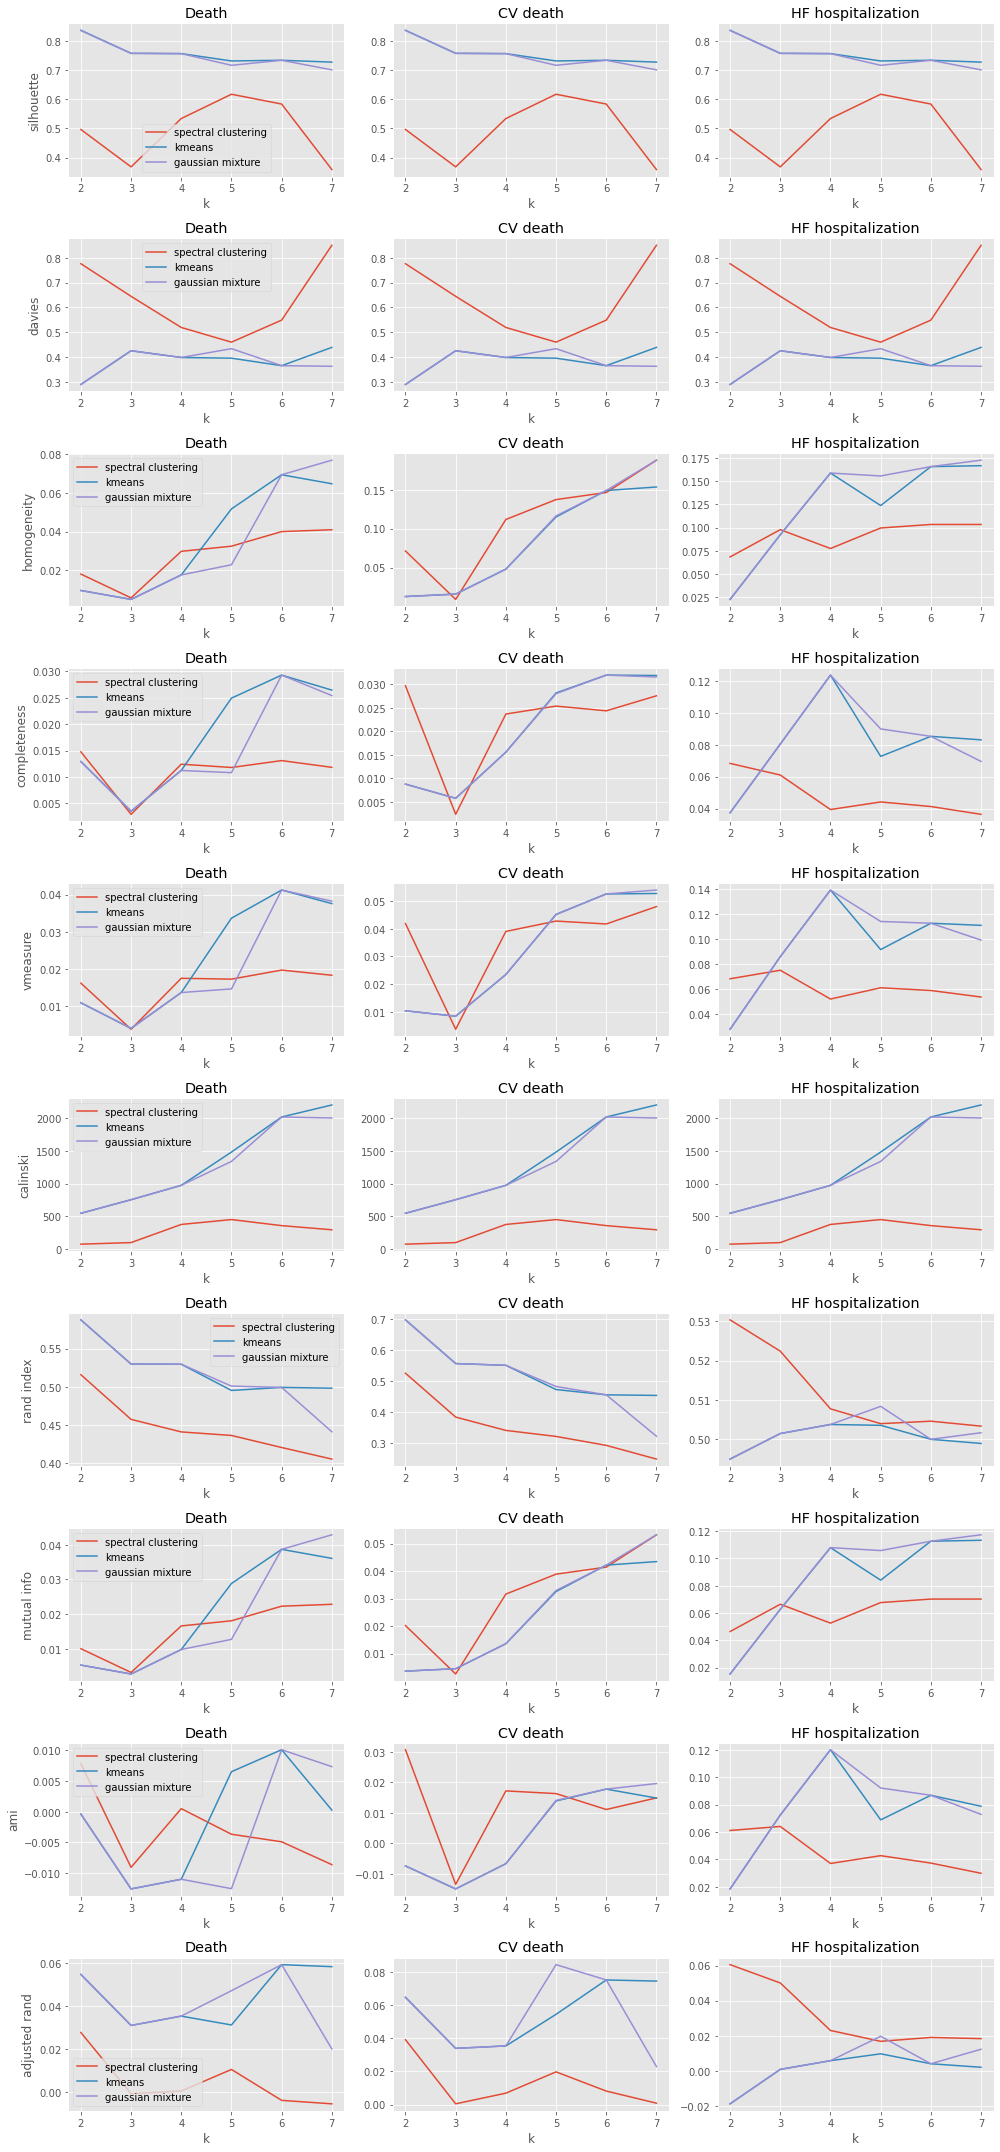

In [11]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

The meaning of the scores.
<!-- * `BIC` lower is better
* `AIC` lower is better -->
* `silhouette` higher is better
* `davies` lower is better
* `homogeneity` higher is better
* `completeness` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `rand index` higher is better
* `mutual info` higher is better

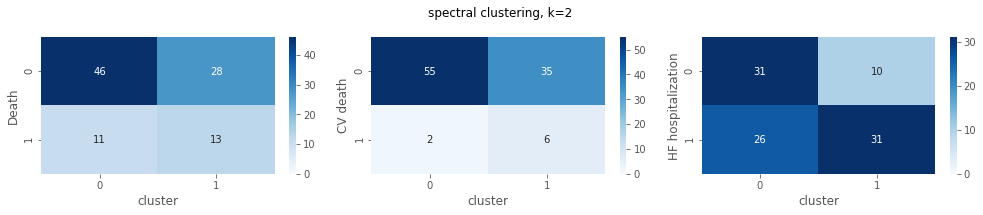

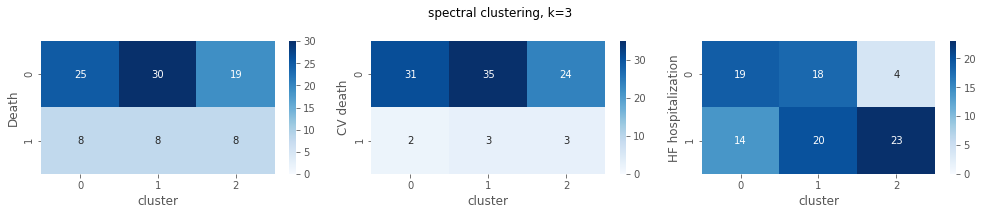

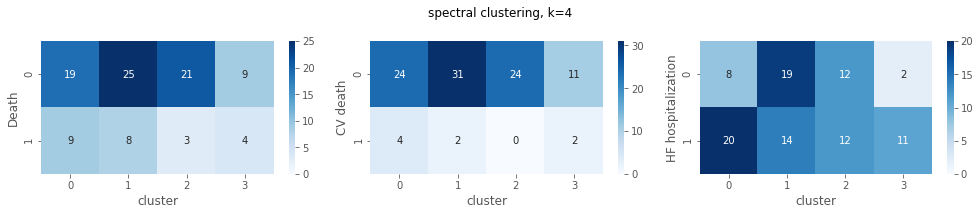

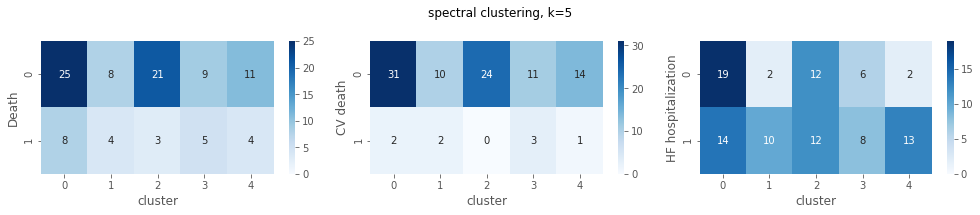

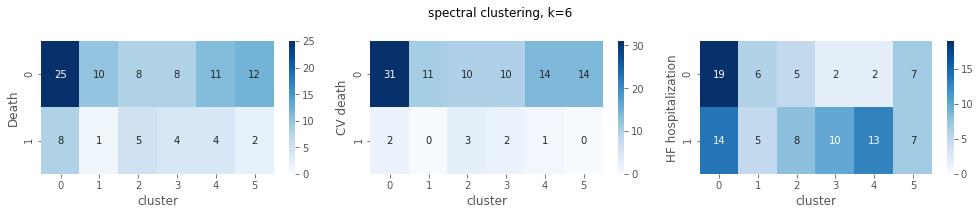

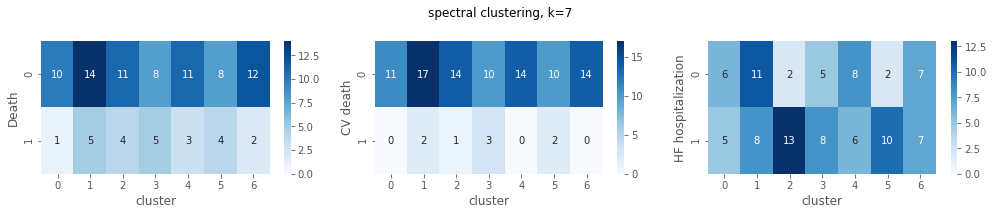

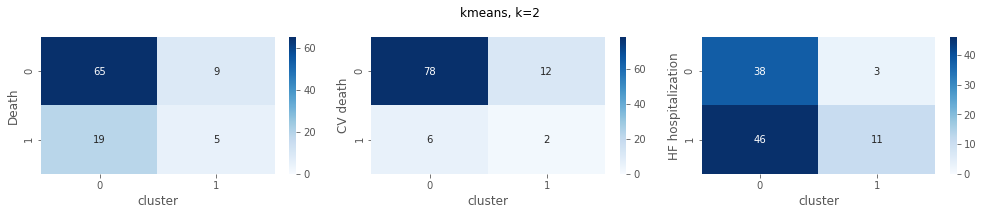

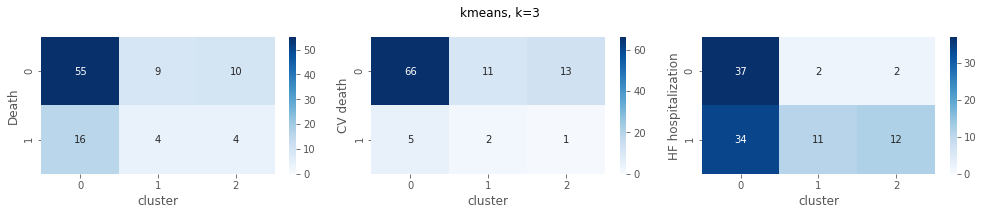

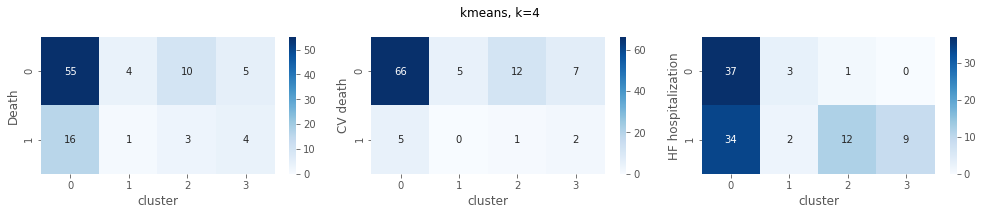

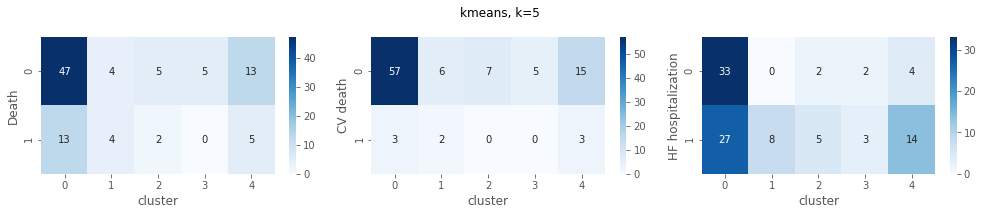

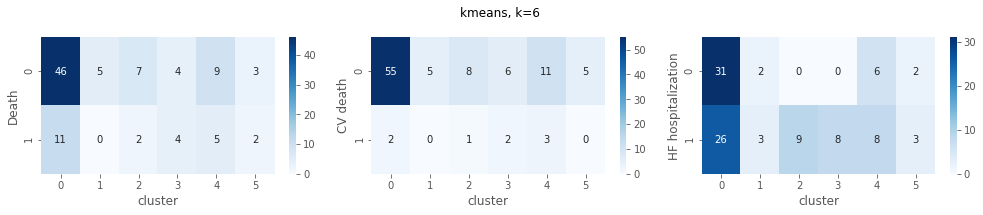

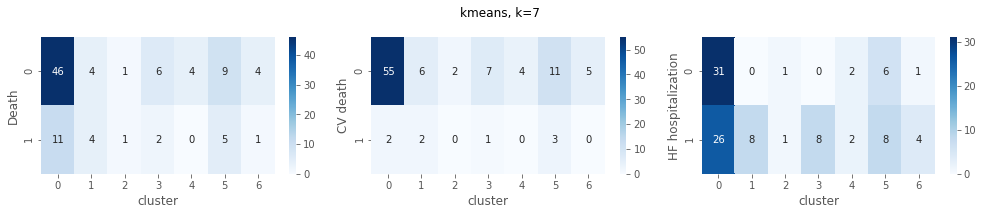

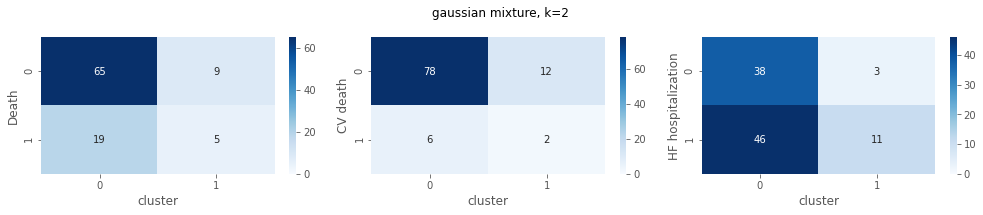

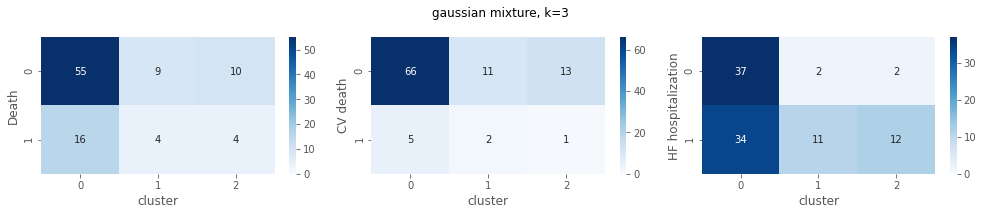

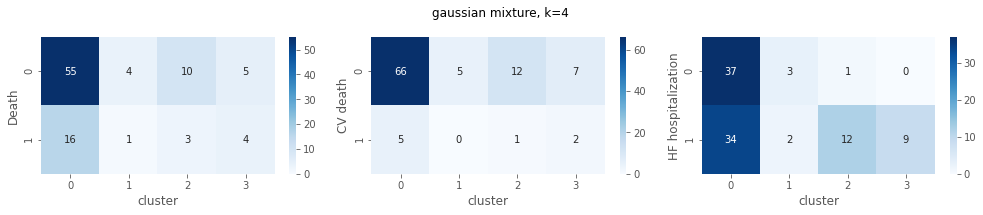

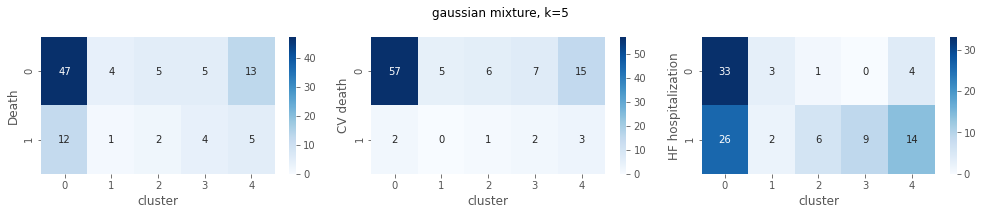

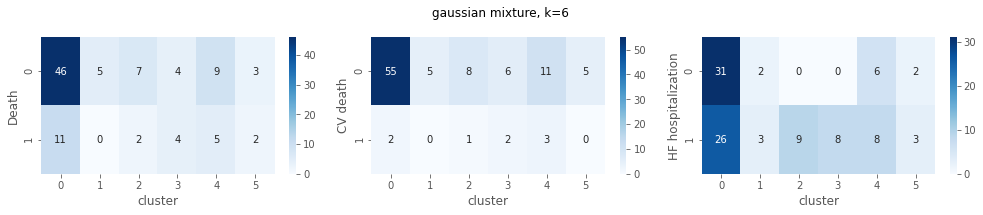

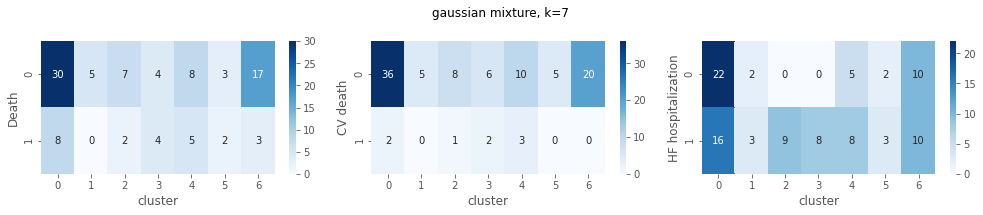

In [12]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [13]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.496200,0.775990,0.018015,0.014752,0.016221,78.525793,0.515885,0.010028,0.007833,0.027686,"[[46, 28], [11, 13]]","[57, 41]"
1,3,0.367986,0.644764,0.005698,0.002912,0.003855,102.465493,0.457395,0.003172,-0.009077,-0.000677,"[[25, 30, 19], [8, 8, 8]]","[33, 38, 27]"
2,4,0.533738,0.519521,0.029813,0.012413,0.017528,378.721491,0.440985,0.016596,0.000505,0.000609,"[[19, 25, 21, 9], [9, 8, 3, 4]]","[28, 33, 24, 13]"
3,5,0.617062,0.460425,0.032472,0.011787,0.017296,452.861810,0.436356,0.018076,-0.003675,0.010578,"[[25, 8, 21, 9, 11], [8, 4, 3, 5, 4]]","[33, 12, 24, 14, 15]"
4,6,0.583419,0.549063,0.040039,0.013092,0.019732,360.773089,0.420576,0.022288,-0.004907,-0.003727,"[[25, 10, 8, 8, 11, 12], [8, 1, 5, 4, 4, 2]]","[33, 11, 13, 12, 15, 14]"
5,7,0.358746,0.850148,0.041008,0.011816,0.018346,297.407241,0.405428,0.022828,-0.008636,-0.005341,"[[10, 14, 11, 8, 11, 8, 12], [1, 5, 4, 5, 3, 4...","[11, 19, 15, 13, 14, 12, 14]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.836172,0.290136,0.009514,0.012914,0.010956,548.566259,0.587629,0.005296,-0.000383,0.054581,"[[65, 9], [19, 5]]","[84, 14]"
1,3,0.757353,0.425848,0.004899,0.003499,0.004082,755.321892,0.529771,0.002727,-0.012594,0.030949,"[[55, 9, 10], [16, 4, 4]]","[71, 13, 14]"
2,4,0.756408,0.398725,0.017595,0.011225,0.013706,974.383560,0.529560,0.009794,-0.011020,0.035272,"[[55, 4, 10, 5], [16, 1, 3, 4]]","[71, 5, 13, 9]"
3,5,0.731246,0.395949,0.051786,0.024927,0.033654,1480.835091,0.495266,0.028827,0.006526,0.031170,"[[47, 4, 5, 5, 13], [13, 4, 2, 0, 5]]","[60, 8, 7, 5, 18]"
4,6,0.733600,0.365787,0.069492,0.029292,0.041212,2014.921141,0.499264,0.038683,0.010115,0.059102,"[[46, 5, 7, 4, 9, 3], [11, 0, 2, 4, 5, 2]]","[57, 5, 9, 8, 14, 5]"
5,7,0.727239,0.439292,0.064825,0.026455,0.037575,2198.170033,0.498212,0.036085,0.000268,0.058161,"[[46, 4, 1, 6, 4, 9, 4], [11, 4, 1, 2, 0, 5, 1]]","[57, 8, 2, 8, 4, 14, 5]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.496200,0.775990,0.068296,0.068296,0.068296,78.525793,0.530402,0.046425,0.061130,0.060544,"[[31, 10], [26, 31]]","[57, 41]"
1,3,0.367986,0.644764,0.097721,0.060996,0.075110,102.465493,0.522407,0.066427,0.064068,0.050092,"[[19, 18, 4], [14, 20, 23]]","[33, 38, 27]"
2,4,0.533738,0.519521,0.077377,0.039341,0.052161,378.721491,0.507679,0.052597,0.037066,0.022988,"[[8, 19, 12, 2], [20, 14, 12, 11]]","[28, 33, 24, 13]"
3,5,0.617062,0.460425,0.099521,0.044115,0.061132,452.861810,0.503892,0.067650,0.042759,0.016796,"[[19, 2, 12, 6, 2], [14, 10, 12, 8, 13]]","[33, 12, 24, 14, 15]"
4,6,0.583419,0.549063,0.103296,0.041246,0.058952,360.773089,0.504523,0.070216,0.037338,0.019019,"[[19, 6, 5, 2, 2, 7], [14, 5, 8, 10, 13, 7]]","[33, 11, 13, 12, 15, 14]"
5,7,0.358746,0.850148,0.103310,0.036350,0.053778,297.407241,0.503261,0.070226,0.029915,0.018328,"[[6, 11, 2, 5, 8, 2, 7], [5, 8, 13, 8, 6, 10, 7]]","[11, 19, 15, 13, 14, 12, 14]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.836172,0.290136,0.022509,0.037309,0.028078,548.566259,0.494845,0.015301,0.018500,-0.018864,"[[38, 3], [46, 11]]","[84, 14]"
1,3,0.757353,0.425848,0.092223,0.080428,0.085923,755.321892,0.501368,0.062689,0.072374,0.000796,"[[37, 2, 2], [34, 11, 12]]","[71, 13, 14]"
2,4,0.756408,0.398725,0.158758,0.123680,0.139040,974.383560,0.503682,0.107917,0.120030,0.005747,"[[37, 3, 1, 0], [34, 2, 12, 9]]","[71, 5, 13, 9]"
3,5,0.731246,0.395949,0.123700,0.072709,0.091585,1480.835091,0.503471,0.084086,0.068866,0.009675,"[[33, 0, 2, 2, 4], [27, 8, 5, 3, 14]]","[60, 8, 7, 5, 18]"
4,6,0.733600,0.365787,0.165662,0.085270,0.112589,2014.921141,0.499895,0.112610,0.086797,0.004007,"[[31, 2, 0, 0, 6, 2], [26, 3, 9, 8, 8, 3]]","[57, 5, 9, 8, 14, 5]"
5,7,0.727239,0.439292,0.166701,0.083074,0.110888,2198.170033,0.498843,0.113317,0.078789,0.001989,"[[31, 0, 1, 0, 2, 6, 1], [26, 8, 1, 8, 2, 8, 4]]","[57, 8, 2, 8, 4, 14, 5]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.836172,0.290136,0.022509,0.037309,0.028078,548.566259,0.494845,0.015301,0.018500,-0.018864,"[[38, 3], [46, 11]]","[84, 14]"
1,3,0.757353,0.425848,0.092223,0.080428,0.085923,755.321892,0.501368,0.062689,0.072374,0.000796,"[[37, 2, 2], [34, 11, 12]]","[71, 13, 14]"
2,4,0.756408,0.398725,0.158758,0.123680,0.139040,974.383560,0.503682,0.107917,0.120030,0.005747,"[[37, 3, 1, 0], [34, 2, 12, 9]]","[71, 5, 13, 9]"
3,5,0.716346,0.434130,0.155613,0.089922,0.113980,1338.305267,0.508311,0.105780,0.092130,0.019676,"[[33, 3, 1, 0, 4], [26, 2, 6, 9, 14]]","[59, 5, 7, 9, 18]"
4,6,0.733600,0.365787,0.165662,0.085270,0.112589,2014.921141,0.499895,0.112610,0.086797,0.004007,"[[31, 2, 0, 0, 6, 2], [26, 3, 9, 8, 8, 3]]","[57, 5, 9, 8, 14, 5]"
5,7,0.700723,0.363326,0.172598,0.069543,0.099140,1999.581889,0.501578,0.117325,0.072867,0.012285,"[[22, 2, 0, 0, 5, 2, 10], [16, 3, 9, 8, 8, 3, ...","[38, 5, 9, 8, 13, 5, 20]"


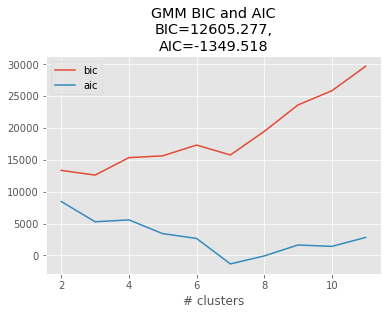

In [14]:
bics, aics = plot_bic_aic(X)

## 2. Selected Feature

In [15]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=True)

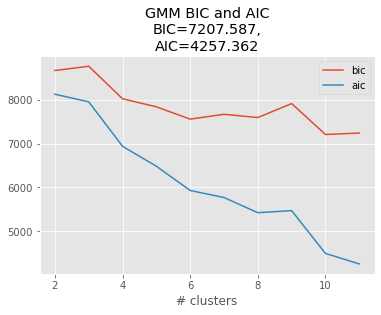

In [16]:
bics, aics = plot_bic_aic(X)

In [17]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

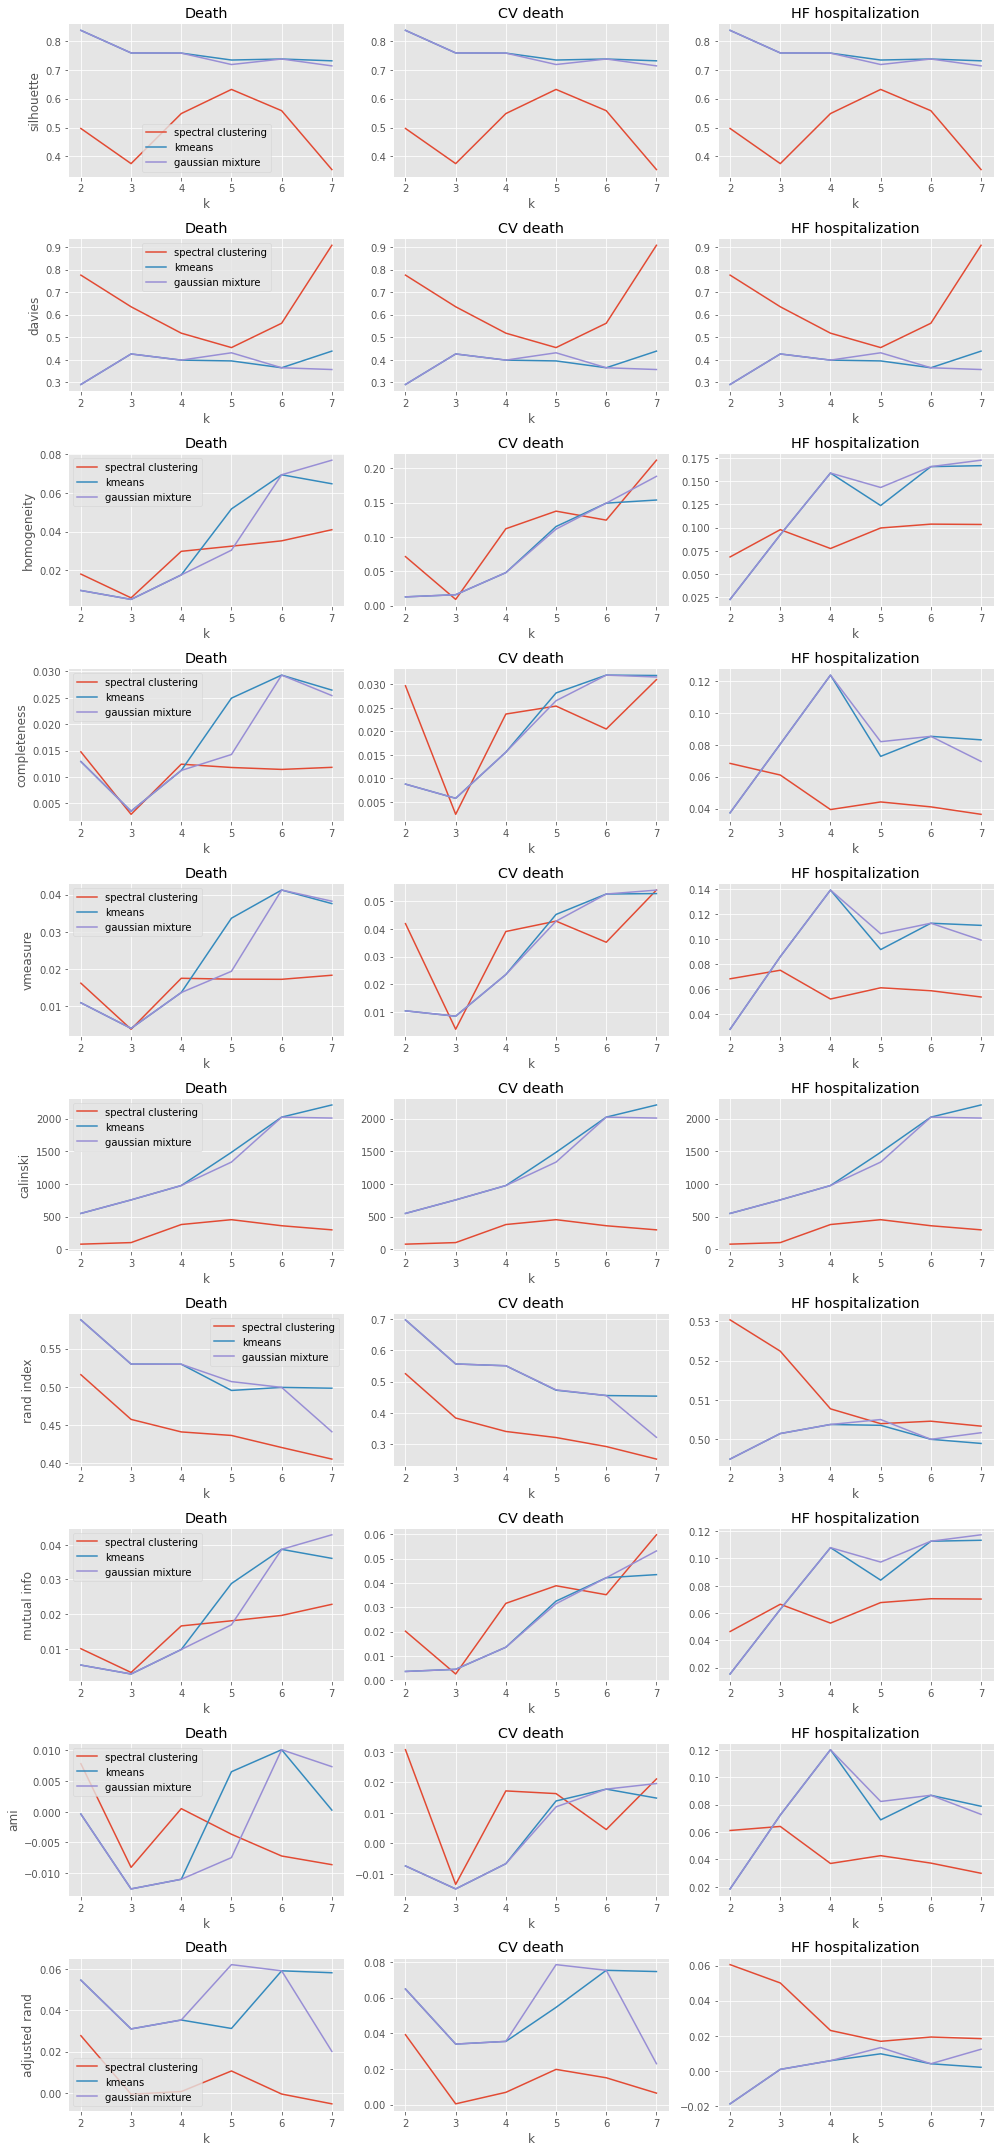

In [18]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

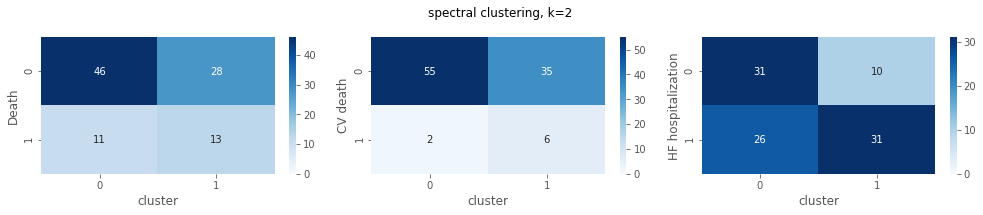

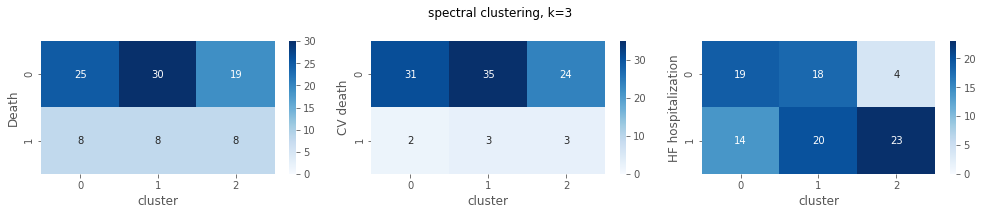

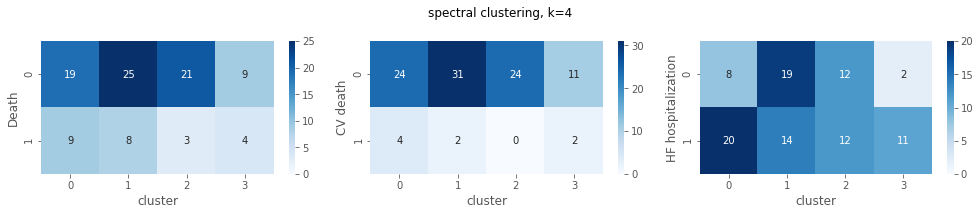

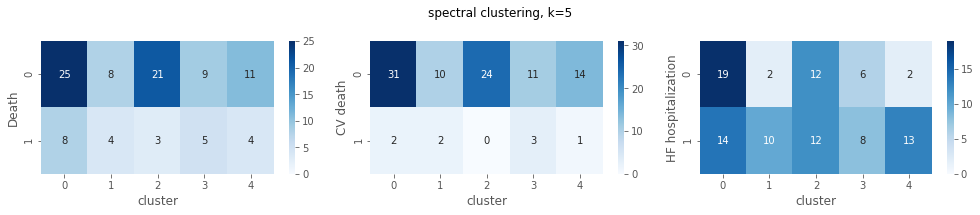

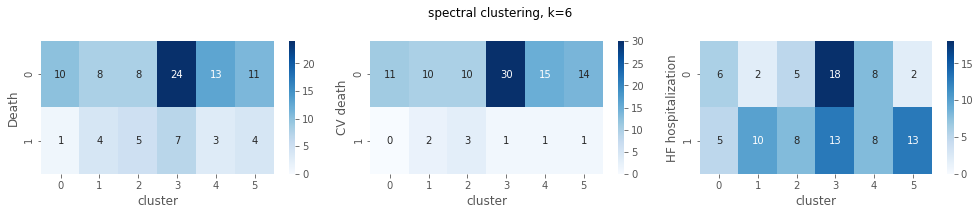

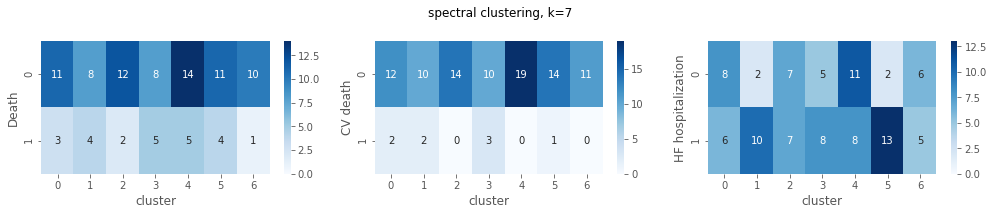

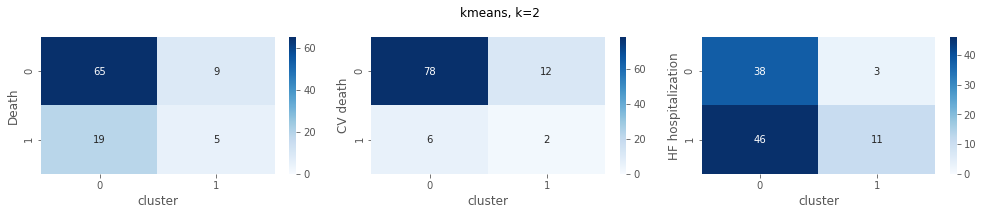

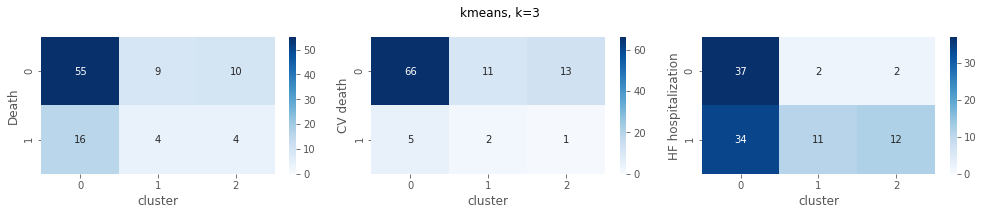

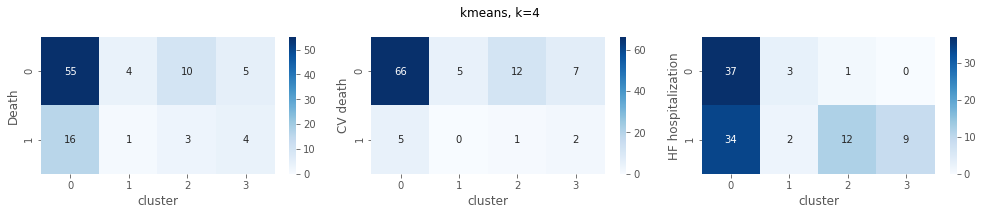

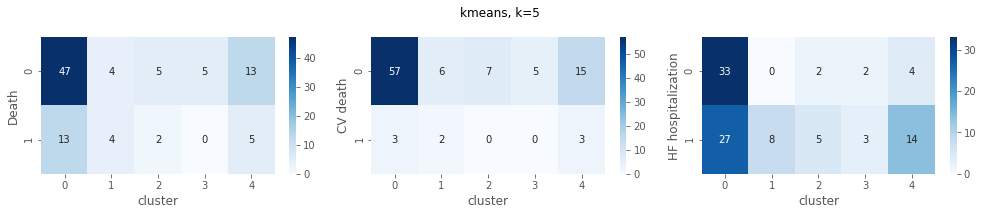

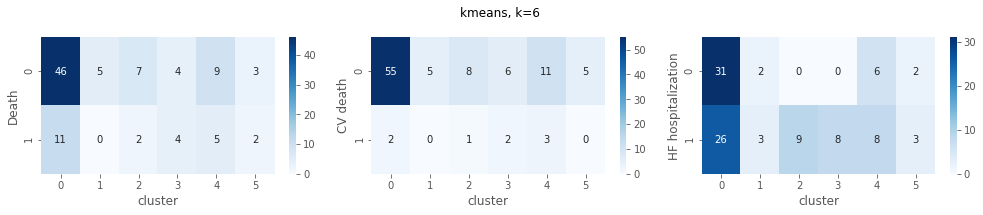

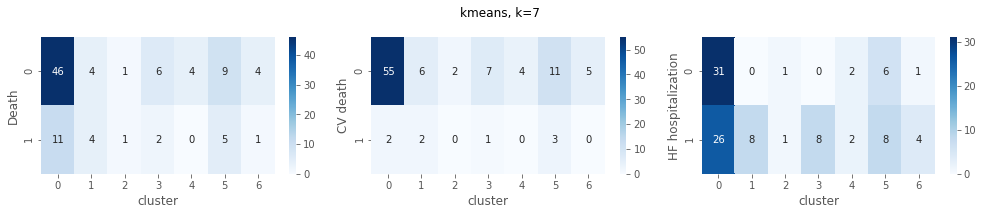

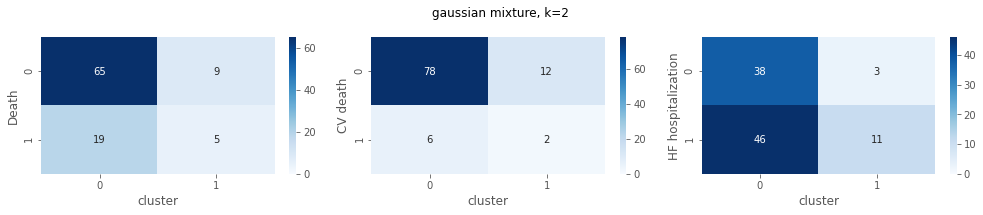

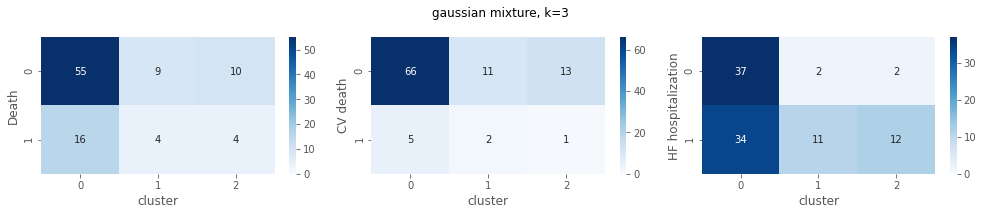

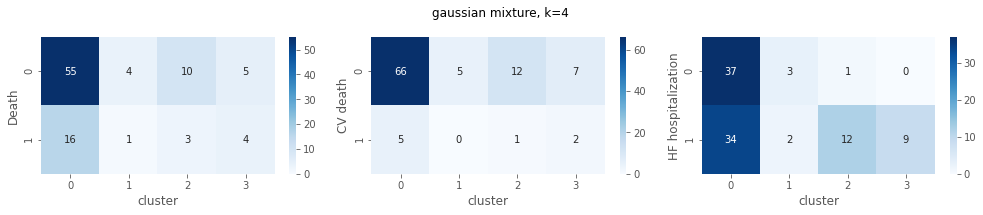

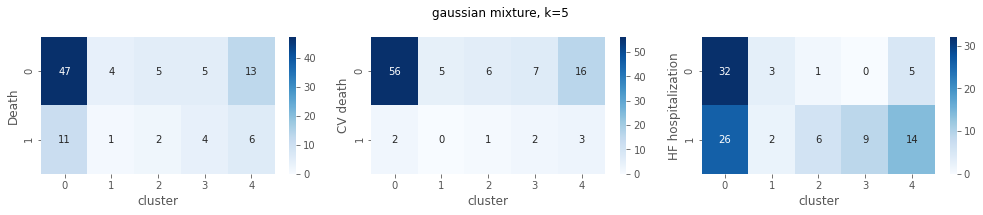

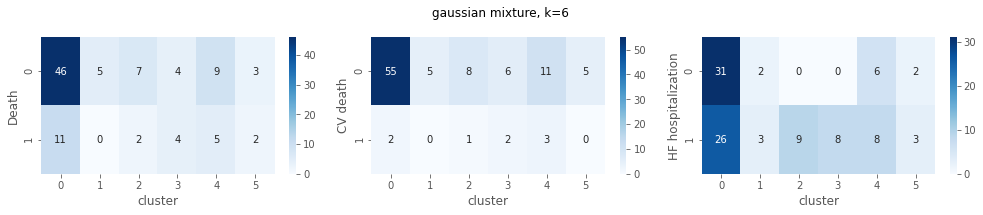

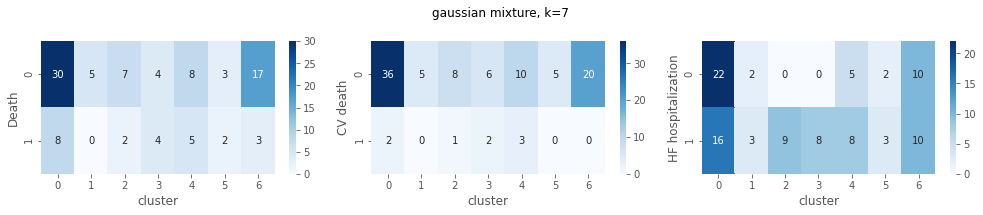

In [19]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [20]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.496902,0.775643,0.018015,0.014752,0.016221,78.530329,0.515885,0.010028,0.007833,0.027686,"[[46, 28], [11, 13]]","[57, 41]"
1,3,0.375274,0.635111,0.005698,0.002912,0.003855,102.476381,0.457395,0.003172,-0.009077,-0.000677,"[[25, 30, 19], [8, 8, 8]]","[33, 38, 27]"
2,4,0.548486,0.517895,0.029813,0.012413,0.017528,378.885499,0.440985,0.016596,0.000505,0.000609,"[[19, 25, 21, 9], [9, 8, 3, 4]]","[28, 33, 24, 13]"
3,5,0.632071,0.453877,0.032472,0.011787,0.017296,453.166067,0.436356,0.018076,-0.003675,0.010578,"[[25, 8, 21, 9, 11], [8, 4, 3, 5, 4]]","[33, 12, 24, 14, 15]"
4,6,0.558418,0.561989,0.035250,0.011423,0.017254,360.340843,0.420576,0.019623,-0.007224,-0.000594,"[[10, 8, 8, 24, 13, 11], [1, 4, 5, 7, 3, 4]]","[11, 12, 13, 31, 16, 15]"
5,7,0.354675,0.908123,0.041008,0.011816,0.018346,297.583646,0.405428,0.022828,-0.008636,-0.005341,"[[11, 8, 12, 8, 14, 11, 10], [3, 4, 2, 5, 5, 4...","[14, 12, 14, 13, 19, 15, 11]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.836513,0.290072,0.009514,0.012914,0.010956,548.692802,0.587629,0.005296,-0.000383,0.054581,"[[65, 9], [19, 5]]","[84, 14]"
1,3,0.758350,0.425564,0.004899,0.003499,0.004082,755.756496,0.529771,0.002727,-0.012594,0.030949,"[[55, 9, 10], [16, 4, 4]]","[71, 13, 14]"
2,4,0.757761,0.398261,0.017595,0.011225,0.013706,975.448206,0.529560,0.009794,-0.011020,0.035272,"[[55, 4, 10, 5], [16, 1, 3, 4]]","[71, 5, 13, 9]"
3,5,0.733824,0.394661,0.051786,0.024927,0.033654,1484.007247,0.495266,0.028827,0.006526,0.031170,"[[47, 4, 5, 5, 13], [13, 4, 2, 0, 5]]","[60, 8, 7, 5, 18]"
4,6,0.737344,0.364312,0.069492,0.029292,0.041212,2022.280851,0.499264,0.038683,0.010115,0.059102,"[[46, 5, 7, 4, 9, 3], [11, 0, 2, 4, 5, 2]]","[57, 5, 9, 8, 14, 5]"
5,7,0.731089,0.438177,0.064825,0.026455,0.037575,2208.634101,0.498212,0.036085,0.000268,0.058161,"[[46, 4, 1, 6, 4, 9, 4], [11, 4, 1, 2, 0, 5, 1]]","[57, 8, 2, 8, 4, 14, 5]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.496902,0.775643,0.068296,0.068296,0.068296,78.530329,0.530402,0.046425,0.061130,0.060544,"[[31, 10], [26, 31]]","[57, 41]"
1,3,0.375274,0.635111,0.097721,0.060996,0.075110,102.476381,0.522407,0.066427,0.064068,0.050092,"[[19, 18, 4], [14, 20, 23]]","[33, 38, 27]"
2,4,0.548486,0.517895,0.077377,0.039341,0.052161,378.885499,0.507679,0.052597,0.037066,0.022988,"[[8, 19, 12, 2], [20, 14, 12, 11]]","[28, 33, 24, 13]"
3,5,0.632071,0.453877,0.099521,0.044115,0.061132,453.166067,0.503892,0.067650,0.042759,0.016796,"[[19, 2, 12, 6, 2], [14, 10, 12, 8, 13]]","[33, 12, 24, 14, 15]"
4,6,0.558418,0.561989,0.103667,0.041021,0.058782,360.340843,0.504523,0.070469,0.037327,0.019250,"[[6, 2, 5, 18, 8, 2], [5, 10, 8, 13, 8, 13]]","[11, 12, 13, 31, 16, 15]"
5,7,0.354675,0.908123,0.103310,0.036350,0.053778,297.583646,0.503261,0.070226,0.029915,0.018328,"[[8, 2, 7, 5, 11, 2, 6], [6, 10, 7, 8, 8, 13, 5]]","[14, 12, 14, 13, 19, 15, 11]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.836513,0.290072,0.022509,0.037309,0.028078,548.692802,0.494845,0.015301,0.018500,-0.018864,"[[38, 3], [46, 11]]","[84, 14]"
1,3,0.758350,0.425564,0.092223,0.080428,0.085923,755.756496,0.501368,0.062689,0.072374,0.000796,"[[37, 2, 2], [34, 11, 12]]","[71, 13, 14]"
2,4,0.757761,0.398261,0.158758,0.123680,0.139040,975.448206,0.503682,0.107917,0.120030,0.005747,"[[37, 3, 1, 0], [34, 2, 12, 9]]","[71, 5, 13, 9]"
3,5,0.733824,0.394661,0.123700,0.072709,0.091585,1484.007247,0.503471,0.084086,0.068866,0.009675,"[[33, 0, 2, 2, 4], [27, 8, 5, 3, 14]]","[60, 8, 7, 5, 18]"
4,6,0.737344,0.364312,0.165662,0.085270,0.112589,2022.280851,0.499895,0.112610,0.086797,0.004007,"[[31, 2, 0, 0, 6, 2], [26, 3, 9, 8, 8, 3]]","[57, 5, 9, 8, 14, 5]"
5,7,0.731089,0.438177,0.166701,0.083074,0.110888,2208.634101,0.498843,0.113317,0.078789,0.001989,"[[31, 0, 1, 0, 2, 6, 1], [26, 8, 1, 8, 2, 8, 4]]","[57, 8, 2, 8, 4, 14, 5]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.836513,0.290072,0.022509,0.037309,0.028078,548.692802,0.494845,0.015301,0.018500,-0.018864,"[[38, 3], [46, 11]]","[84, 14]"
1,3,0.758350,0.425564,0.092223,0.080428,0.085923,755.756496,0.501368,0.062689,0.072374,0.000796,"[[37, 2, 2], [34, 11, 12]]","[71, 13, 14]"
2,4,0.757761,0.398261,0.158758,0.123680,0.139040,975.448206,0.503682,0.107917,0.120030,0.005747,"[[37, 3, 1, 0], [34, 2, 12, 9]]","[71, 5, 13, 9]"
3,5,0.718252,0.430785,0.143187,0.081923,0.104219,1334.484629,0.504944,0.097332,0.082278,0.013239,"[[32, 3, 1, 0, 5], [26, 2, 6, 9, 14]]","[58, 5, 7, 9, 19]"
4,6,0.737344,0.364312,0.165662,0.085270,0.112589,2022.280851,0.499895,0.112610,0.086797,0.004007,"[[31, 2, 0, 0, 6, 2], [26, 3, 9, 8, 8, 3]]","[57, 5, 9, 8, 14, 5]"
5,7,0.713608,0.356454,0.172598,0.069543,0.099140,2008.307604,0.501578,0.117325,0.072867,0.012285,"[[22, 2, 0, 0, 5, 2, 10], [16, 3, 9, 8, 8, 3, ...","[38, 5, 9, 8, 13, 5, 20]"


## Get Cleaned Data

In [21]:
data_df_clean = get_hfpef_100_nomiss_selected_feats()

In [23]:
data_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 51 entries, 1 to 97
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 51 non-null     int64  
 1   Sex                 51 non-null     int64  
 2   Cr                  51 non-null     float64
 3   GFR                 51 non-null     float64
 4   CKD stage           51 non-null     int64  
 5   AF                  51 non-null     int64  
 6   MAP                 51 non-null     float64
 7   PP                  51 non-null     int64  
 8   NTProBNP            51 non-null     float64
 9   medial a'           51 non-null     float64
 10  medial E'           51 non-null     float64
 11  LAVI                51 non-null     float64
 12  LA diameter         51 non-null     float64
 13  Death               51 non-null     int64  
 14  CV death            51 non-null     int64  
 15  HF hospitalization  51 non-null     int64  
dtypes: float64

In [24]:
data_df_clean.describe()

,Age,Sex,Cr,GFR,CKD stage,AF,MAP,PP,NTProBNP,medial a',medial E',LAVI,LA diameter,Death,CV death,HF hospitalization
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,72.235294,1.627451,2.000980,50.958431,2.862745,0.215686,93.490196,71.764706,9129.700784,7.794118,5.083333,29.774510,2.411765,0.176471,0.078431,0.627451
std,11.885433,0.488294,1.922055,29.636126,1.249314,0.415390,10.019393,19.344858,11348.285521,2.668111,1.659339,24.976924,2.109848,0.385013,0.271524,0.488294
min,34.000000,1.000000,0.630000,2.000000,1.000000,0.000000,70.000000,25.000000,41.740000,2.020000,2.760000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,67.000000,1.000000,0.875000,22.000000,2.000000,0.000000,87.500000,60.000000,1174.500000,6.220000,3.685000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,75.000000,2.000000,1.130000,58.000000,3.000000,0.000000,94.333333,69.000000,3493.000000,7.770000,4.760000,30.900000,3.500000,0.000000,0.000000,1.000000
75%,78.500000,2.000000,2.225000,73.000000,4.000000,0.000000,100.000000,81.500000,12887.000000,9.870000,6.290000,42.100000,4.100000,0.000000,0.000000,1.000000
max,92.000000,2.000000,10.000000,105.000000,5.000000,1.000000,117.000000,124.000000,35001.000000,12.800000,9.160000,107.700000,6.000000,1.000000,1.000000,1.000000


## 3. Cleaned Data

In [25]:
X, y, feature_list = convert2np(data_df_clean, lbl_colname, selected_feat=True)

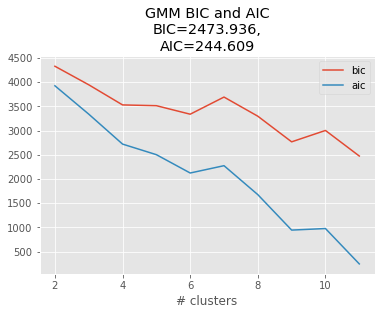

In [26]:
bics, aics = plot_bic_aic(X)

In [27]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

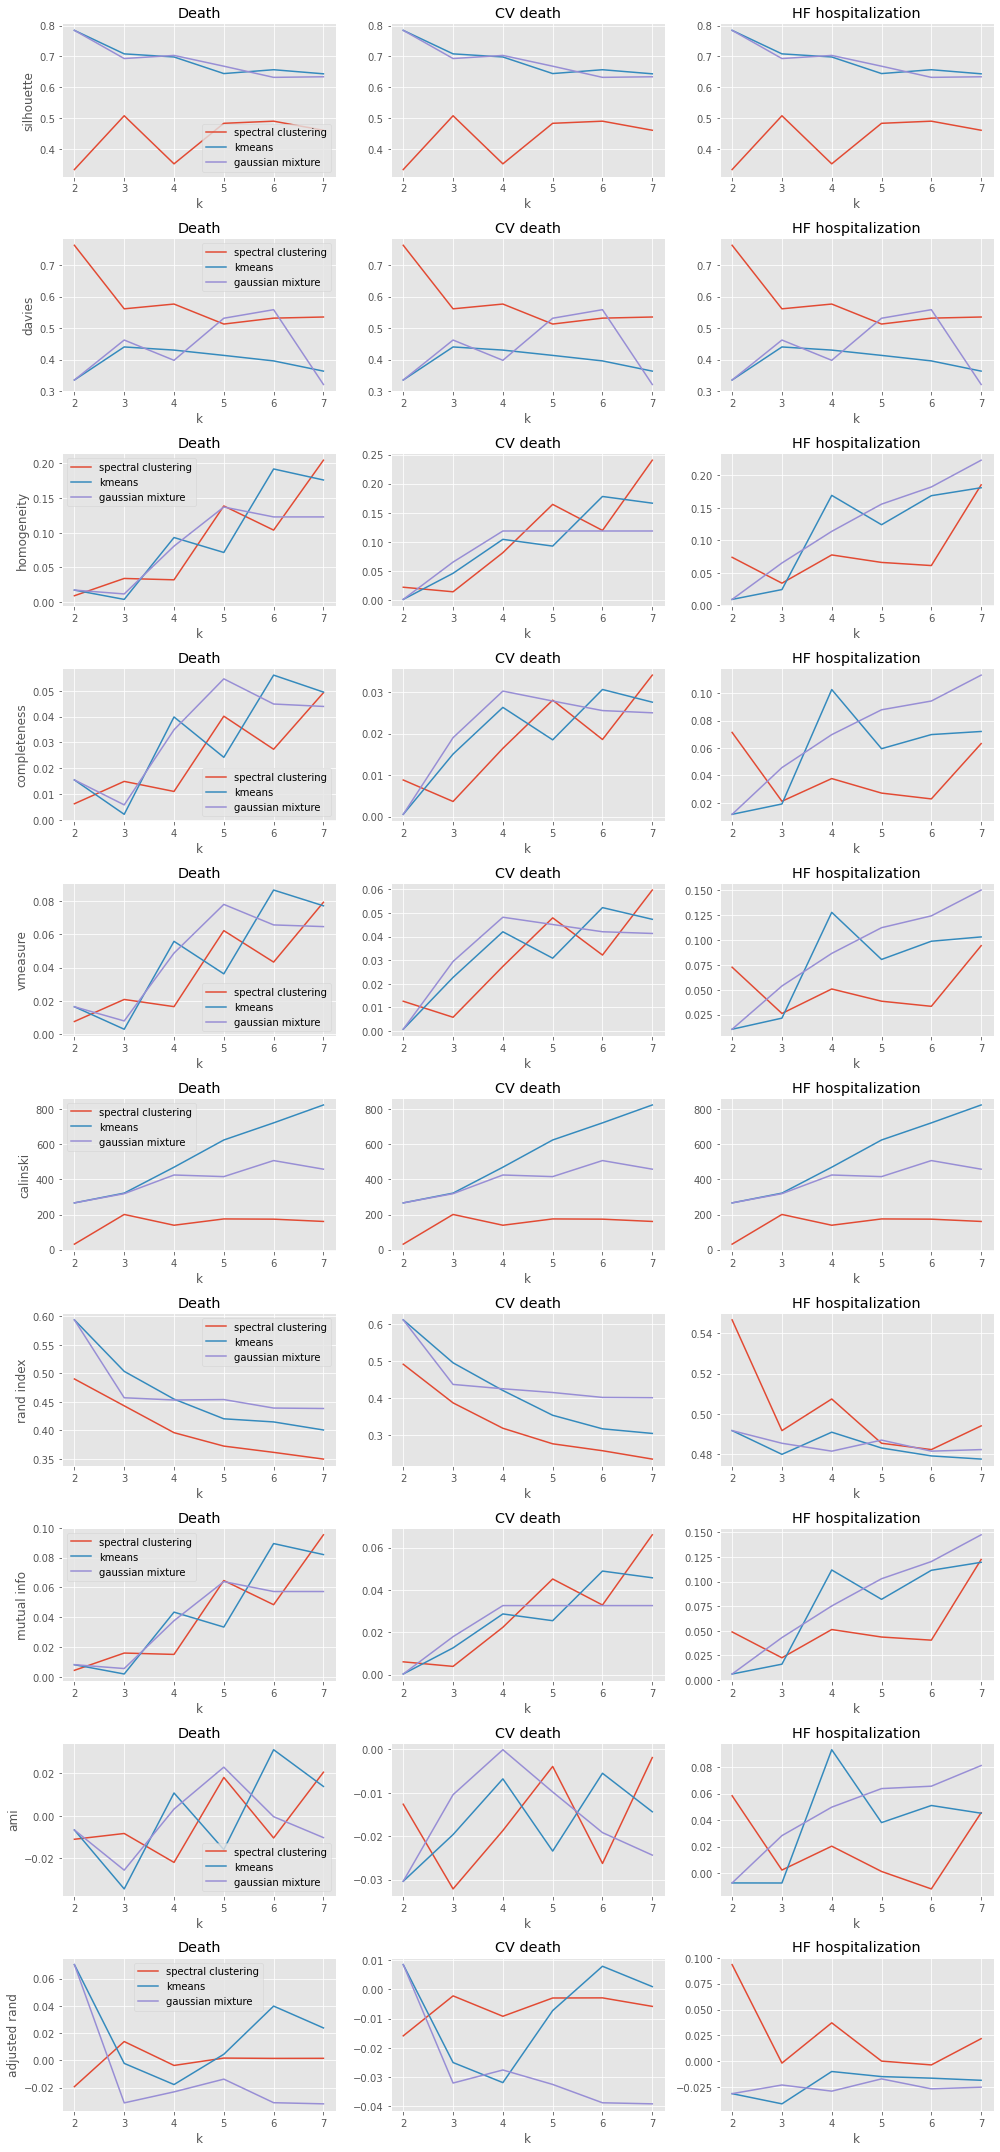

In [28]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

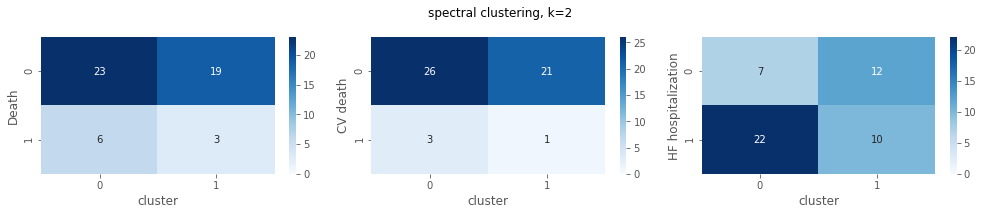

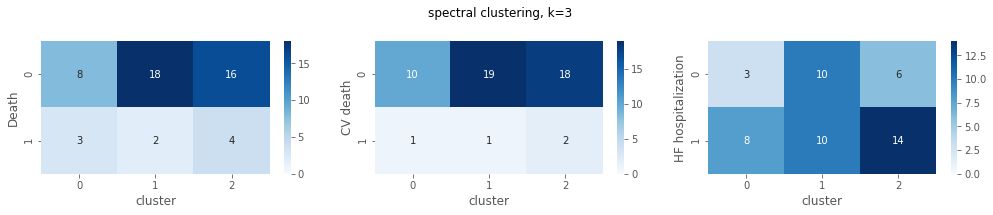

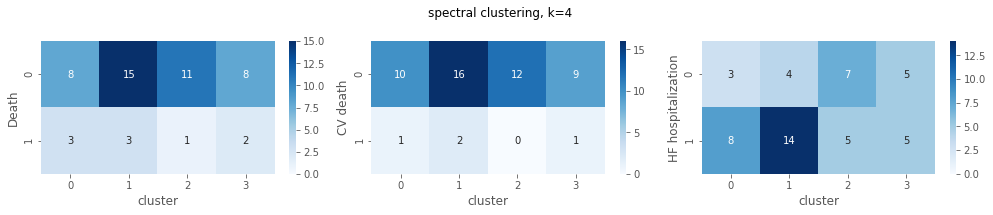

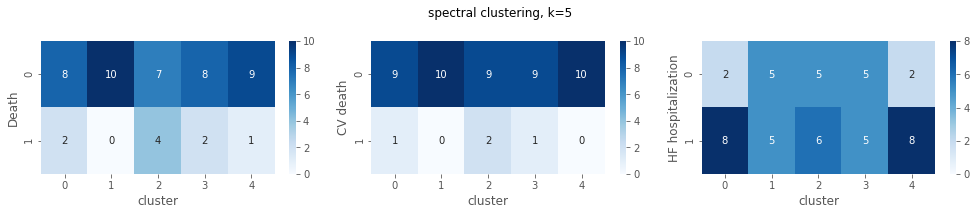

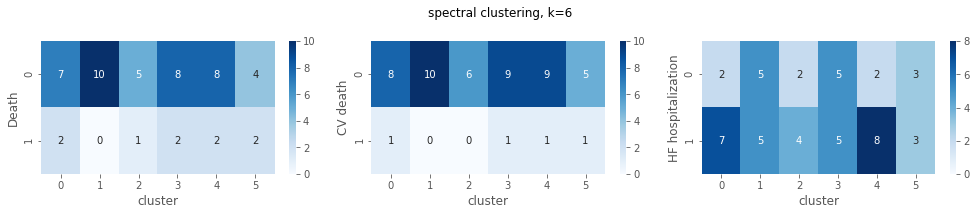

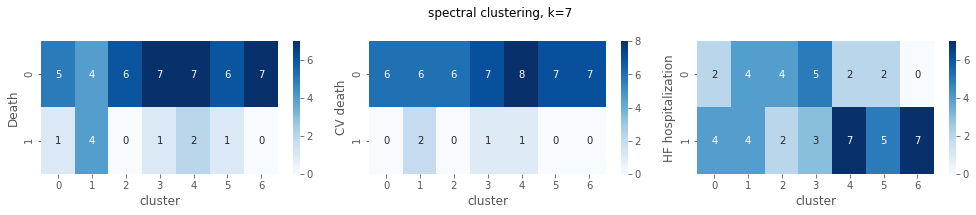

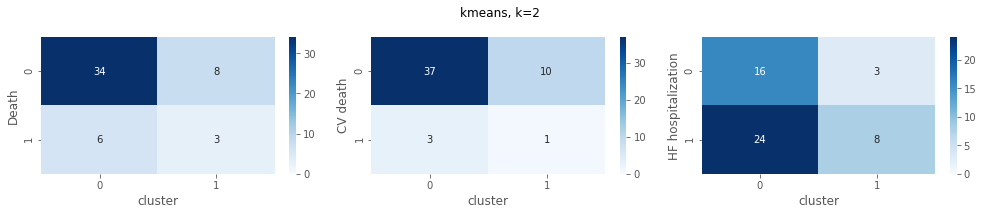

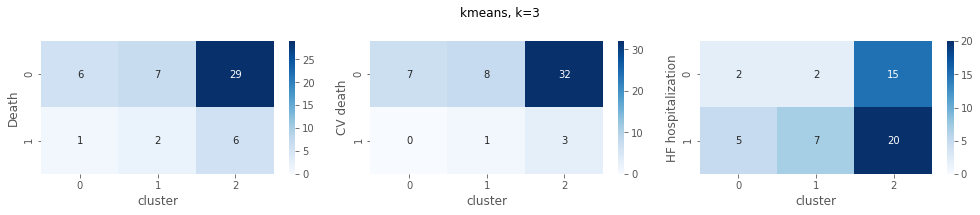

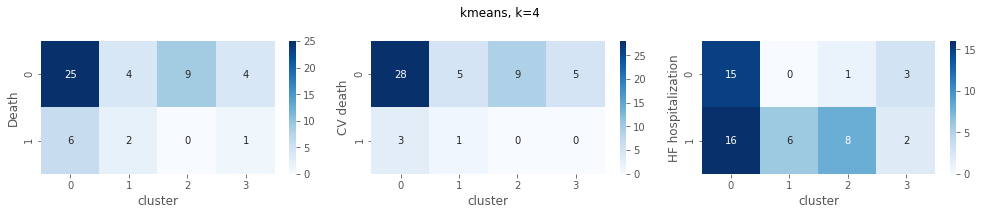

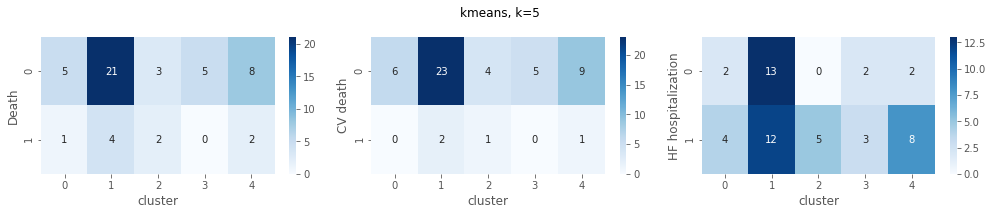

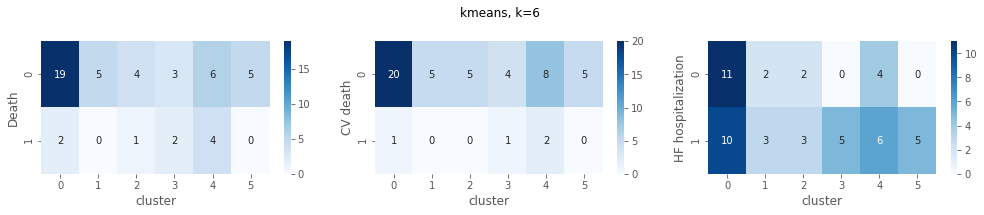

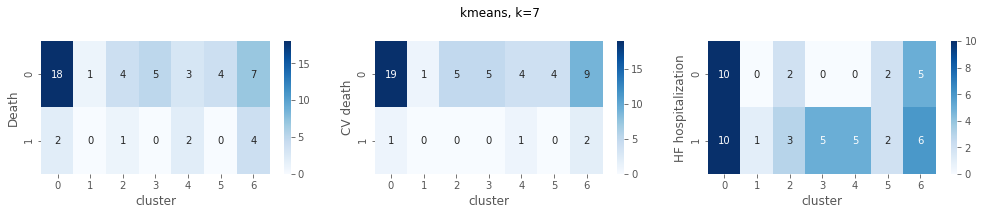

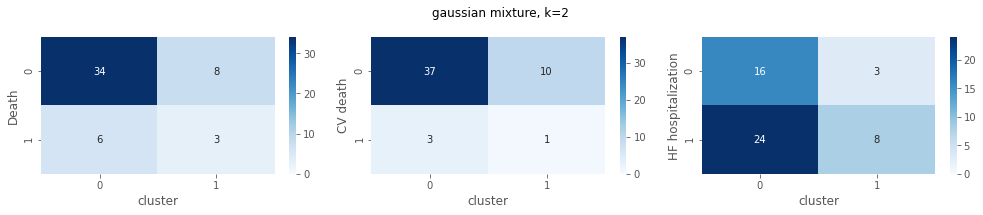

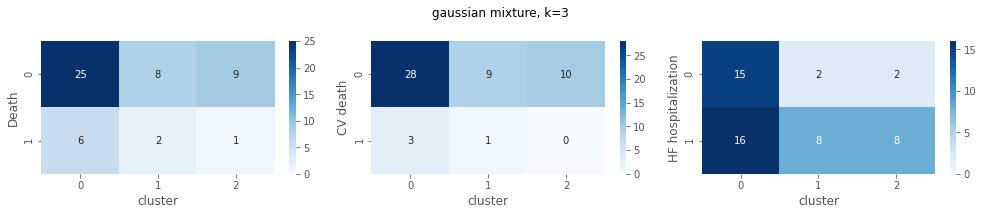

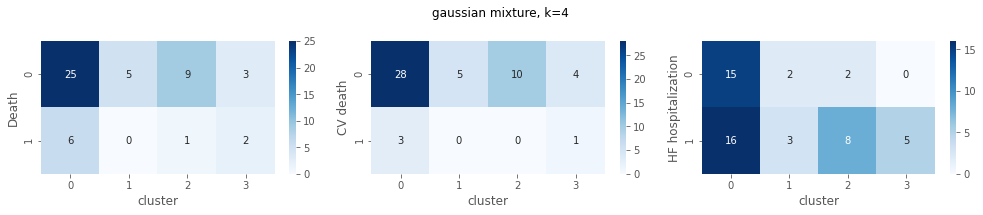

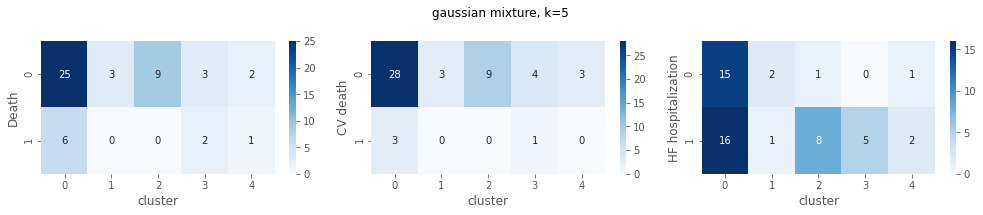

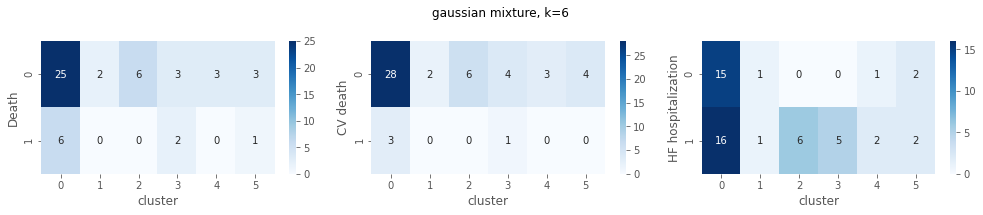

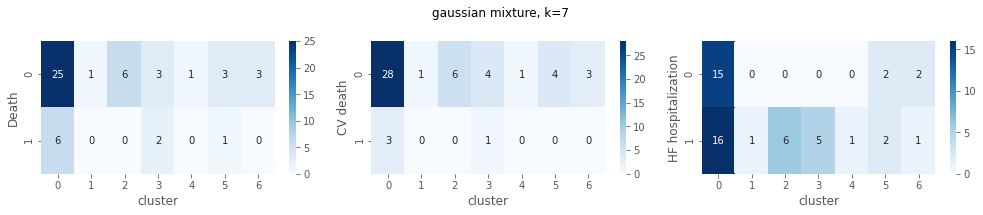

In [29]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [30]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.332462,0.762305,0.009196,0.006268,0.007455,31.441587,0.490196,0.004285,-0.011021,-0.019282,"[[23, 19], [6, 3]]","[29, 22]"
1,3,0.507168,0.561078,0.034115,0.014927,0.020767,200.500594,0.443137,0.015898,-0.008296,0.013792,"[[8, 18, 16], [3, 2, 4]]","[11, 20, 20]"
2,4,0.351015,0.576195,0.032161,0.011033,0.016430,139.179493,0.396078,0.014987,-0.021914,-0.003717,"[[8, 15, 11, 8], [3, 3, 1, 2]]","[11, 18, 12, 10]"
3,5,0.482621,0.512887,0.138719,0.040184,0.062316,175.055956,0.372549,0.064643,0.018079,0.001674,"[[8, 10, 7, 8, 9], [2, 0, 4, 2, 1]]","[10, 10, 11, 10, 10]"
4,6,0.489524,0.531577,0.103850,0.027372,0.043325,173.736700,0.361569,0.048394,-0.010415,0.001449,"[[7, 10, 5, 8, 8, 4], [2, 0, 1, 2, 2, 2]]","[9, 10, 6, 10, 10, 6]"
5,7,0.460052,0.535154,0.204708,0.049275,0.079431,160.709238,0.349804,0.095394,0.020535,0.001496,"[[5, 4, 6, 7, 7, 6, 7], [1, 4, 0, 1, 2, 1, 0]]","[6, 8, 6, 8, 9, 7, 7]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.784346,0.335653,0.017341,0.015498,0.016368,266.391959,0.593725,0.008081,-0.006646,0.070195,"[[34, 8], [6, 3]]","[40, 11]"
1,3,0.708048,0.440340,0.003902,0.002173,0.002791,322.023992,0.503529,0.001819,-0.034389,-0.002220,"[[6, 7, 29], [1, 2, 6]]","[7, 9, 35]"
2,4,0.697939,0.430374,0.093146,0.039889,0.055858,469.485329,0.454902,0.043406,0.010765,-0.017738,"[[25, 4, 9, 4], [6, 2, 0, 1]]","[31, 6, 9, 5]"
3,5,0.644083,0.413594,0.071605,0.024248,0.036228,624.433638,0.420392,0.033368,-0.015895,0.004469,"[[5, 21, 3, 5, 8], [1, 4, 2, 0, 2]]","[6, 25, 5, 5, 10]"
4,6,0.656567,0.396135,0.192058,0.056092,0.086826,721.838554,0.414902,0.089499,0.031125,0.039795,"[[19, 5, 4, 3, 6, 5], [2, 0, 1, 2, 4, 0]]","[21, 5, 5, 5, 10, 5]"
5,7,0.643290,0.363802,0.176173,0.049523,0.077313,823.800734,0.400784,0.082097,0.013839,0.023787,"[[18, 1, 4, 5, 3, 4, 7], [2, 0, 1, 0, 2, 0, 4]]","[20, 1, 5, 5, 5, 4, 11]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.332462,0.762305,0.073934,0.071404,0.072647,31.441587,0.546667,0.048818,0.058434,0.093366,"[[7, 12], [22, 10]]","[29, 22]"
1,3,0.507168,0.561078,0.034135,0.021163,0.026128,200.500594,0.491765,0.022539,0.002242,-0.001746,"[[3, 10, 6], [8, 10, 14]]","[11, 20, 20]"
2,4,0.351015,0.576195,0.077601,0.037723,0.050767,139.179493,0.507451,0.051240,0.020298,0.037162,"[[3, 4, 7, 5], [8, 14, 5, 5]]","[11, 18, 12, 10]"
3,5,0.482621,0.512887,0.066076,0.027121,0.038458,175.055956,0.485490,0.043630,0.001176,0.000191,"[[2, 5, 5, 5, 2], [8, 5, 6, 5, 8]]","[10, 10, 11, 10, 10]"
4,6,0.489524,0.531577,0.061259,0.022878,0.033315,173.736700,0.482353,0.040450,-0.012027,-0.003499,"[[2, 5, 2, 5, 2, 3], [7, 5, 4, 5, 8, 3]]","[9, 10, 6, 10, 10, 6]"
5,7,0.460052,0.535154,0.185422,0.063242,0.094316,160.709238,0.494118,0.122434,0.045618,0.021854,"[[2, 4, 4, 5, 2, 2, 0], [4, 4, 2, 3, 7, 5, 7]]","[6, 8, 6, 8, 9, 7, 7]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.784346,0.335653,0.009184,0.011631,0.010264,266.391959,0.491765,0.006064,-0.007498,-0.031255,"[[16, 3], [24, 8]]","[40, 11]"
1,3,0.708048,0.440340,0.024297,0.019166,0.021429,322.023992,0.480000,0.016043,-0.007545,-0.041096,"[[2, 2, 15], [5, 7, 20]]","[7, 9, 35]"
2,4,0.697939,0.430374,0.169241,0.102695,0.127826,469.485329,0.490980,0.111750,0.093251,-0.009866,"[[15, 0, 1, 3], [16, 6, 8, 2]]","[31, 6, 9, 5]"
3,5,0.644083,0.413594,0.124079,0.059538,0.080465,624.433638,0.483137,0.081929,0.038146,-0.014758,"[[2, 13, 0, 2, 2], [4, 12, 5, 3, 8]]","[6, 25, 5, 5, 10]"
4,6,0.656567,0.396135,0.168751,0.069835,0.098788,721.838554,0.479216,0.111426,0.051065,-0.016302,"[[11, 2, 2, 0, 4, 0], [10, 3, 3, 5, 6, 5]]","[21, 5, 5, 5, 10, 5]"
5,7,0.643290,0.363802,0.181009,0.072098,0.103122,823.800734,0.477647,0.119520,0.045222,-0.018354,"[[10, 0, 2, 0, 0, 2, 5], [10, 1, 3, 5, 5, 2, 6]]","[20, 1, 5, 5, 5, 4, 11]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.784346,0.335653,0.009184,0.011631,0.010264,266.391959,0.491765,0.006064,-0.007498,-0.031255,"[[16, 3], [24, 8]]","[40, 11]"
1,3,0.692856,0.462231,0.065203,0.045728,0.053756,318.799660,0.485490,0.043054,0.028270,-0.022894,"[[15, 2, 2], [16, 8, 8]]","[31, 10, 10]"
2,4,0.702974,0.398059,0.113873,0.069786,0.086538,425.134167,0.481569,0.075190,0.049809,-0.028835,"[[15, 2, 2, 0], [16, 3, 8, 5]]","[31, 5, 10, 5]"
3,5,0.668010,0.531294,0.155759,0.087925,0.112400,415.930827,0.487059,0.102847,0.063852,-0.016987,"[[15, 2, 1, 0, 1], [16, 1, 8, 5, 2]]","[31, 3, 9, 5, 3]"
4,6,0.631769,0.558349,0.182192,0.094326,0.124299,507.237285,0.481569,0.120301,0.065668,-0.026616,"[[15, 1, 0, 0, 1, 2], [16, 1, 6, 5, 2, 2]]","[31, 2, 6, 5, 3, 4]"
5,7,0.633681,0.321491,0.223359,0.113226,0.150274,458.264989,0.482353,0.147483,0.081288,-0.024990,"[[15, 0, 0, 0, 0, 2, 2], [16, 1, 6, 5, 1, 2, 1]]","[31, 1, 6, 5, 1, 4, 3]"
